# **Problem Statement**

## Business Context

Legal aid providers assisting tenants with rental disputes face increasing operational pressure. They must interpret statutory guidance, review lease clauses, and reference prior judgments while responding to a high volume of tenant inquiries.

Currently, this process is largely manual:

- Staff consult internal PDFs and prior case records.

- Clarifications must be requested repeatedly (e.g., notice period, tenancy duration, jurisdiction).

- Responses vary depending on staff experience and time constraints.

- Delays increase the risk of missed deadlines and procedural errors.

Unlike general internet searches, tenant-landlord disputes require structured reasoning, controlled document grounding, and escalation safeguards. A simple search engine cannot reliably enforce document boundaries, validate statutory relevance, or abstain when legal support is insufficient.

Therefore, an agent-based system is required to coordinate parsing, retrieval, validation, and response generation within a controlled workflow.

## Dataset

The following data files are provided and will be used by the AI agent-based system as source documents.

- `tenants_rights.pdf`: The document is a guide that explains residential tenants' rights and protections, covering topics such as types of housing, leases, rent, eviction, habitability, safety, utility services, and personal protections against discrimination and harassment
- `previous_judgements.pdf`: The document is an archive of past rental law case records detailing the parties, legal issues, statutes cited, verdicts, and court holdings on topics like security deposits, eviction, rent increases, habitability, and succession rights.

# **Installing and Importing Necessary Libraries**

In [ ]:
!pip install openai==1.66.3 \
            langchain==0.3.20 \
            langchain-openai==0.3.9 \
            langchain_experimental==0.3.4 \
            pypdf==5.4.0 \
            langgraph==0.3.21 \
            chromadb==1.4.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of langchain-community to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of langchain-community to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 567.4/567.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:
# ===============================
# Core Python
# ===============================
import os
import json
from typing import TypedDict, List, Set, Optional, Dict, Any
from decimal import Decimal
import time
import re
import datetime

# ===============================
# LangChain Core
# ===============================
from langchain_core.messages import (
    SystemMessage,
    HumanMessage,
    AIMessage,
    ToolMessage,
    BaseMessage
)
from langchain_core.tools import tool

# ===============================
# LangChain OpenAI
# ===============================
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

# ===============================
# Vector Store + Document Processing
# ===============================
from langchain.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.vectorstores import Chroma

# ===============================
# LangGraph
# ===============================
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages

# ===============================
# LangSmith (Tracing)
# ===============================
from langsmith import traceable, Client

# **LLM and Agent Observability Setup**

#### LangSmith Setup

In a multi-agent system, multiple agents and tools may run in sequence, passing state and intermediate results between them. As the workflow grows in complexity, it becomes challenging to understand:

- why a particular routing decision was made,
- which documents or chunks were retrieved,
- where an incorrect or unexpected output originated,

and more.

LangSmith provides observability for agentic AI workflows by logging:

- the end-to-end execution flow
- all tool and agent calls
- intermediate inputs and outputs
- key performance metrics

With LangSmith, one can debug errors, evaluate system behavior, and validate that a workflow is executing as intended. Without this level of tracing, diagnosing issues in complex agentic AI workflows becomes time-consuming and error-prone.

**How to obtain a LangSmith API Key?**

1. Visit: [https://smith.langchain.com](https://smith.langchain.com)  
2. Sign in and go to **Settings → API Keys**  
3. Generate a new API key  
4. Store this key securely (for example, in a `config.json` file or environment variables)

Example `config.json`:

```json
{
  "LANGCHAIN_TRACING_V2": "true",
  "LANGCHAIN_API_KEY": "your_langsmith_api_key",
  "LANGCHAIN_PROJECT": "your_langsmith_project_name"
}
```

**Note**: The API key enables tracing for the specific project workspace.

#### OpenAI API Setup

The credentials for OpenAI setup need to be stored in the same `config.json` file as the LangSmith credentials.

Example `config.json`:

```json
{
  "LANGCHAIN_TRACING_V2": "true",
  "LANGCHAIN_API_KEY": "your_langsmith_api_key",
  "LANGCHAIN_PROJECT": "your_langsmith_project_name",
  "OPENAI_API_KEY": "your_openai_key",
  "OPENAI_API_BASE": "your_openai_base_url"
}

We load all OpenAI and LangSmith credentials from a secure `config.json` file and store them as environment variables.

In [ ]:
# Load the JSON file and extract values
file_name = 'config.json'                                                       # Name of the configuration file
with open(file_name, 'r') as file:                                              # Open the config file in read mode
    config = json.load(file)                                                    # Load the JSON content as a dictionary

    OPENAI_API_KEY = config.get("OPENAI_API_KEY")                               # Extract OpenAI API key
    OPENAI_API_BASE = config.get("OPENAI_API_BASE")                             # Extract OpenAI base URL

    LANGCHAIN_TRACING_V2 = config.get("LANGCHAIN_TRACING_V2")                   # Extract LangSmith tracing flag
    LANGCHAIN_API_KEY = config.get("LANGCHAIN_API_KEY")                         # Extract LangSmith API key
    LANGCHAIN_PROJECT = config.get("LANGCHAIN_PROJECT")                         # Extract LangSmith project name


# Store OpenAI credentials in environment variables
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY                                   # Set OpenAI API key
os.environ['OPENAI_BASE_URL'] = OPENAI_API_BASE                                 # Set OpenAI API base URL


# Store LangSmith credentials in environment variables
os.environ['LANGCHAIN_TRACING_V2'] = LANGCHAIN_TRACING_V2                       # Enable LangSmith tracing
os.environ['LANGCHAIN_API_KEY'] = LANGCHAIN_API_KEY                             # Set LangSmith API key
os.environ['LANGCHAIN_PROJECT'] = LANGCHAIN_PROJECT                             # Set LangSmith project

For the problem at hand, we will use two LLMs to separate responsibilities
- a lightweight model for primary reasoning and generation, and
- a more complex model for evaluation and validation, ensuring better accuracy, reliability, and cost efficiency.


In [ ]:
# Initialize LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Initialize separate LLM for validation (more complex model)
eval_llm = ChatOpenAI(model="gpt-4o", temperature=0)

# **Multi-Agent System Architecture**

We will design a structured, policy-first multi-agent architecture for a residential tenant-landlord legal reasoning system. The objective is to enforce strict domain validation, enable evidence-grounded document retrieval, and ensure modular, traceable reasoning across specialized agents.


<font size=4>**1. Orchestration Agent**</font>

This agent acts as the central routing controller of the system.

* Determines which agent should execute next based on the current shared state
* Ensures the correct execution order (Parse → Response → Quality Audit)
* Immediately terminates processing for out-of-scope queries
* Prevents redundant execution once a final response is generated
* Maintains deterministic control over workflow transitions

In short, it governs system flow and enforces structured execution logic.

<font size=4>**2. Parse Agent**</font>

This agent performs structured query validation and refinement before any retrieval occurs.

* Applies deterministic keyword-based validation to confirm tenant–landlord scope
* Extracts structured fields:

  * User Intent
  * Property Type
  * Tenancy Type
  * Key Legal Issues
* Uses an LLM validation layer to:

  * Correct or refine the parsed structure
  * Detect missing or ambiguous legal details
  * Assign a structural confidence score
* Triggers Human-in-the-Loop (HITL) clarification when legally essential facts are missing
* Produces a structured, validated representation for downstream retrieval

This agent ensures only clean, well-defined, in-scope legal queries proceed to downstream agents.

<font size=4>**3. Response Agent (Policy-First RAG Agent)**</font>

This agent performs controlled retrieval and grounded legal answer generation.

It follows a strict tool-driven workflow:

**Policy Retrieval (Primary Source)**

* Retrieves statutory/policy chunks using recursive expansion
* Avoids duplicate retrieval via ID tracking
* Expands search scope up to three attempts

**Case Retrieval (Secondary Support)**

* Retrieves at most one relevant case
* Uses case content strictly as supporting authority

**Validation**

* Validates whether retrieved content is sufficient
* Assigns a retrieval confidence score

**Grounded Answer Generation**

* Generates the final response strictly grounded in retrieved evidence
* Prohibits outside knowledge or speculation
* Keeps statutory explanation primary
* References case law only as supporting authority

This agent ensures evidence-driven, controlled, and non-hallucinatory legal responses.

<font size=4>**4. Response Quality Audit Agent**</font>

This agent evaluates the final output before delivery.

It performs three layers of evaluation:

**A. Relevance & Groundedness Check**

* Scores how directly the answer addresses the query
* Scores how well the answer is supported by retrieved evidence
* Stores evaluator notes for traceability

**B. Structural & Execution Evaluation**

* Verifies required tools were called
* Ensures `reply_tool` terminated the workflow correctly
* Computes tool accuracy
* Calculates reasoning trajectory coherence

**C. HITL Post-Generation Gate**

* Compares scores against configurable thresholds
* Automatically escalates:
  * Low confidence
  * Weak grounding
  * Poor logical coherence
  * Structural tool violations
* Replaces output with a human-review notice if required
* Records latency and trace metadata

This agent ensures the system does not deliver weak, hallucinated, or structurally invalid legal responses.

## Agent State

**`UnifiedState`** defines the shared state schema that carries query data, intermediate agent outputs, retrieval metadata, routing decisions, and the final response across all agents in the multi-agent workflow.


In [ ]:
class UnifiedState(TypedDict,total=False):
    # ─── Core Query ────────────────────────────────────────────────
    user_query:                  str
    messages:                    List[BaseMessage]

    # ─── Parse Agent ───────────────────────────────────────────────
    parsed_output:               str
    refined_output:              str
    parse_confidence:            float

    # ─── HITL-1 Clarification ──────────────────────────────────────
    clarification_requested:     bool    # True after first clarification attempt
    clarification_query:         str     # The clarifying question posed to user
    user_clarification_response: str     # User's answer to clarification question

    # ─── Response Agent ──────────────────────────────────────
    case_chunks:                 str
    legal_chunks:                str
    validation_status:           str
    retrieval_attempt:           int
    seen_legal_ids:              Set[str]
    rag_chunks_confidence:       float
    tool_call_log:               List[str]

    # ─── Relevance & Groundedness Agent ────────────────────────────
    relevance_score:             float   # 0.0-1.0: answer addresses the query
    groundedness_score:          float   # 0.0-1.0: answer grounded in evidence
    relevance_groundedness_notes: str    # Evaluator explanation

    # ─── Orchestration ─────────────────────────────────────────────
    next_agent:                  str
    next_route:                 str

    # ─── Final Response ────────────────────────────────────────────
    final_output:                str

    # ─── Evaluation Metrics ────────────────────────────────────────
    correct_termination:         bool
    tool_accuracy:               bool
    reasoning_coherence:         float

    # ─── HITL Flags ────────────────────────────────────────────────
    hitl_1_triggered:            bool
    hitl_2_triggered:            bool
    hitl_stage:                  str

    # ─── Efficiency Tracking ───────────────────────────────────────
    run_start_time:              float   # time.time() at graph entry
    run_end_time:                float   # time.time() at graph exit
    total_latency_seconds:       float   # end - start
    langsmith_run_id:            str     # for fetching per-run trace details

## Agent 1: Orchestration Agent

Here, we use a **deterministic, rule-based orchestration agent** to control the execution flow across agents.

The routing logic is explicitly predefined and condition-driven.

1. **Parsing First:** If no parsed output exists in the state, the orchestrator routes the workflow to the Parse Agent.

2. **Scope Check Next:** After parsing, it checks whether the query has been marked as `OUT_OF_SCOPE`. If so, it finalizes the response immediately and terminates the workflow.

3. **Response Step:** If the query is in scope and marked for further processing (`next_route == response_agent`), and no final answer has been generated yet, it routes execution to the Response Agent.

4. **Mandatory Quality Gate**: If the Response Agent has generated a response and requested a final check (`next_agent == response_quality_audit_agent`), the orchestrator passes control to the Response Quality Audit Agent.

5. **Default Termination:** If none of these conditions apply, the orchestrator ends the workflow without invoking additional agents.

This ensures strict execution order and prevents unnecessary agent invocation.


In [ ]:
@traceable(name='orchestrator_node')
def orchestrator_node(state: UnifiedState):
    """
    Central routing controller.
    Decides which agent runs next.
    """

    # First entry
    if not state.get('parsed_output'):
        state['next_agent'] = 'parse_agent'
        return state

    # Out-of-scope fast exit
    if 'OUT_OF_SCOPE' in state.get('refined_output', ''):
        state['final_output'] = "OUT_OF_SCOPE: This agent handles residential rental law queries only. Please ask an in-scope question."
        state['next_agent']   = 'END'
        return state

    # Handle Routing to Response Agent
    if (
        state.get('next_route') == 'response_agent'
        and not state.get('final_output')
    ):
        state['next_agent'] = 'response_agent'
        return state

    # Handle Routing to Response Quality Audit Agent
    if state.get('next_agent') == 'response_quality_audit_agent':
        return state

    # Default - done
    state['next_agent'] = 'END'
    return state

## Agent 2: Parse Agent

The **Parse Agent** serves as a structured validation and preprocessing layer with built-in confidence scoring and clarification control.

It uses three tools:

* **`parse_query`** – A rule-based validator that confirms tenant–landlord scope and extracts structured fields (intent, property type, tenancy type, legal issues).
* **`validate_and_refine_parsed_query`** – An LLM-based validator that corrects structure, ensures completeness, assigns a confidence score, and flags if clarification is needed.
* **`clarification_query`** – Generates one legally essential follow-up question when required and captures the user’s response.

This ensures strict domain control, clean structured input, early ambiguity detection, and controlled Human-in-the-Loop intervention before retrieval begins.


> **Note:** The confidence score reflects how certain the agent is about the correctness and completeness of the generated answer, and it later contributes to the overall Reasoning Trajectory Coherence calculation in the final evaluation stage.

### JSON Parse Function

We define a utility function that safely extracts and parses a valid JSON object from raw LLM output (handling markdown fences and format inconsistencies) and returns it as a dictionary, raising an error if extraction fails.


In [ ]:
def extract_json_to_dict(llm_output: Any) -> Dict:
    """
    Safely extracts and parses JSON from LLM output.

    Args:
        llm_output: Raw response from LLM (string or dict)

    Returns:
        Parsed dictionary

    Raises:
        ValueError if valid JSON cannot be extracted.
    """

    # If already a dict, return directly
    if isinstance(llm_output, dict):
        return llm_output

    if not isinstance(llm_output, str):
        raise ValueError("Unsupported LLM output type.")

    raw = llm_output.strip()

    # Remove markdown fences if present
    if raw.startswith("```"):
        raw = re.sub(r"^```[a-zA-Z]*", "", raw)
        raw = raw.replace("```", "").strip()

    # Extract JSON block
    match = re.search(r"\{.*\}", raw, re.DOTALL)
    if not match:
        raise ValueError("No valid JSON object found in LLM output.")

    try:
        return json.loads(match.group())
    except json.JSONDecodeError as e:
        raise ValueError(f"Invalid JSON format: {e}")

### Tool: Parse Query

This tool checks whether a query is about tenant-landlord issues and, if so, extracts a lightweight structure:
- high-level intent,
- basic housing context (property/tenancy type), and
- key legal issue tags

, returning them as a readable summary for downstream agents.

In [ ]:
@tool
def parse_query(query: str) -> str:
    """
    Parse and validate a tenant legal query.
    Rejects non-tenant law queries.
    """

    q = query.lower()

    # Domain guardrail
    tenant_keywords = [
        # Parties & roles
        "tenant", "renter", "landlord", "property owner",
        "property manager", "housing authority",

        # Tenancy & lease structure
        "lease", "rental agreement", "tenancy agreement",
        "fixed term", "month-to-month", "renewal",
        "early termination", "sublease",

        # Rent, fees & money
        "rent", "rent payment", "rent increase", "rent stabilized",
        "nonpayment", "late fee", "application fee",
        "broker fee", "pet fee",

        # Eviction, notices & court
        "eviction", "notice to quit", "notice of termination",
        "pay or quit", "housing court", "court summons",
        "notice period", "written notice", "30 day notice",

        # Security deposit & move-out condition
        "security deposit", "deposit refund", "deposit deductions",
        "normal wear and tear", "move out", "move in",
        "move-out inspection", "vacate",

        # Repairs, safety & habitability
        "repair", "maintenance", "habitability",
        "unsafe conditions", "code violation", "housing code",
        "mold", "leak", "infestation", "pest",
        "plumbing", "electricity", "gas", "smoke detector",

        # Access, privacy & retaliation
        "right of entry", "entry notice", "privacy",
        "harassment", "retaliation", "lockout",
        "illegal lockout", "utility shutoff",

        # Discrimination & accommodations
        "discrimination", "fair housing",
        "reasonable accommodation", "disability accommodation",
        "service animal", "emotional support animal",
        "source of income discrimination",

        # Property & use restrictions
        "apartment", "unit", "house", "condo",
        "room rental", "occupancy limit",
        "certificate of occupancy", "illegal apartment",
        "short term rental", "airbnb",

        # Utilities & services
        "utilities", "electric bill", "water bill", "gas bill"
    ]

    if not any(k in q for k in tenant_keywords):
        return (
            "OUT_OF_SCOPE:\n"
            "This agent handles tenant-landlord (rental) law only.\n"
            "Please ask an in-scope question."
        )

    # --- Intent detection ---
    if "evict" in q or "eviction" in q:
        intent = "Eviction Defense / Eviction Process"
    elif "rent increase" in q or "raise rent" in q:
        intent = "Rent Control / Rent Increase Legality"
    elif "security deposit" in q:
        intent = "Security Deposit Dispute"
    elif "repair" in q or "habitability" in q:
        intent = "Repairs & Habitability Rights"
    elif "lease" in q:
        intent = "Lease Review / Interpretation"
    elif "retaliation" in q:
        intent = "Tenant Retaliation Claim"
    elif "discrimination" in q:
        intent = "Housing Discrimination"
    else:
        intent = "General Tenant Rights Inquiry"


    # --- Housing context ---
    property_type = "Unspecified Residential Unit"
    if "apartment" in q:
        property_type = "Apartment"
    elif "house" in q:
        property_type = "Single-family Home"
    elif "condo" in q:
        property_type = "Condominium"

    tenancy_type = "Unspecified"
    if "month-to-month" in q:
        tenancy_type = "Month-to-Month"
    elif "fixed term" in q or "1 year" in q:
        tenancy_type = "Fixed-Term Lease"

    # --- Legal issues ---
    legal_issues = []

    if "notice" in q:
        legal_issues.append("Notice requirements")
    if "deposit" in q:
        legal_issues.append("Security deposit handling")
    if "repair" in q:
        legal_issues.append("Implied warranty of habitability")
    if "lockout" in q:
        legal_issues.append("Illegal lockout")
    if "rent" in q:
        legal_issues.append("Rent payment obligations")

    if not legal_issues:
        legal_issues.append("General tenant protections")


    # --- Output ---
    return f"""
Parsed Tenant Law Query
-----------------------

Scope Validation:
- Tenant / Landlord Law: CONFIRMED

User Intent:
- {intent}

Property Type:
- {property_type}

Tenancy Type:
- {tenancy_type}

Key Legal Issues:
- """ + "\n- ".join(legal_issues) + f"""
"""

### Tool: Validate and Refine Parsed Query (with Confidence Score)

This tool implements an LLM-based validation node that returns three outputs:

* **Parsed_Query** – The validated and refined structured tenant-law query
* **Human_Needed** – YES/NO flag indicating whether clarification is required
* **confidence** – A structural certainty score assigned by the validator


In [ ]:
@tool
def validate_and_refine_parsed_query(query: str, parsed_output: str) -> str:
    """
    LLM validation layer.
    Returns structured JSON string or 'OUT_OF_SCOPE' string.
    """

    VALIDATION_PROMPT = f"""
You are a strict validation and correction layer for a legal AI system that handles ONLY residential tenant–landlord (rental housing) law.

INPUTS:
ORIGINAL USER QUERY:
{query}

INITIAL PARSED OUTPUT:
{parsed_output}

TASK:
1. Confirm the query is residential tenant–landlord law.
2. Validate and correct the parsed output.
3. Determine if human clarification is required.
4. Assign a confidence score for your structural validation.

RULES:

1) OUT-OF-SCOPE
If NOT residential tenant–landlord law, return exactly:
OUT_OF_SCOPE: This agent handles residential rental law queries only. Please ask an in-scope question.
Do NOT return JSON.

2) PARSER VALIDATION
- Keep structure if accurate.
- Correct partially incorrect fields.
- Fully reframe if significantly incorrect.
- Do NOT invent facts.
- If information is missing, write "Unspecified".
- Ensure ALL four fields exist:
  • User Intent
  • Property Type
  • Tenancy Type
  • Key Legal Issues

3) HUMAN_NEEDED (STRICT RULE)
Return "YES" if:
- Any fields is missing
- Any field is "Unspecified"
- Any field is overly general or not clearly derived from the query
- The issue lacks sufficient specificity

Return "NO" only if all fields are present and specific.

4) CONFIDENCE
0.95–1.0  → Very high certainty
0.75–0.94 → Minor ambiguity
0.50–0.74 → Moderate uncertainty
<0.50     → Low certainty

OUTPUT FORMAT (JSON ONLY):

{{
  "Parsed_Query": "Parsed Tenant Law Query\n---\nScope Validation:\n- Tenant / Landlord Law: CONFIRMED\n\nUser Intent:\n\nProperty Type:\n\nTenancy Type:\n\nKey Legal Issues:\n",
  "Human_Needed": "YES or NO",
  "confidence": 0.00
}}

Do not modify field names. Do not add fields. No explanations.
"""

    raw_response_content = eval_llm.invoke(VALIDATION_PROMPT).content

    return raw_response_content

### Tool: Clarification Query

LLM-based clarification node that generates one legally essential follow-up question from the parsed query, captures the user's response, and returns both the clarification question and response in structured JSON for updating the shared state and continuing the workflow.


In [ ]:
@tool
def clarification_query(query: str, parsed_query: str) -> dict:
    """
    Generates one targeted clarification question for the user.
    In production: pause graph, await real user input, then resume.
    In this implementation: uses input() for interactive demo,
    with a fallback simulation for automated test runs.
    """

    # ── Step 1: Generate targeted clarification question ──────────
    clarification_prompt = f"""
You are a clarification generation layer in a residential tenant–landlord AI system.

INPUTS:

USER QUERY:
{query}

PARSED DATA:
{parsed_query}

TASK:
Generate exactly ONE legally essential clarification question that is required to properly answer the original user query.

RULES:
- Always return one question.
- Do NOT ask about jurisdiction, state, country, or location.
- Do NOT repeat information already clearly provided.
- Prioritize the most critical missing legal fact such as:
  • Written or oral lease
  • Fixed-term or periodic tenancy
  • Length of tenancy
  • Notice type or notice duration
  • Date of notice
  • Rent amount or increase percentage
  • Whether notice was written
  • Whether rent is unpaid
  • Whether repairs were formally requested

If multiple details are missing, ask the single most legally important for answering the original user query.

STRICT OUTPUT FORMAT:
Return ONLY valid JSON:

{{
  "Clarification Question": "Your single clarification question"
}}

No explanations.
No additional text.
"""

    # Enforce JSON output for the clarification question and parse it
    try:
        raw_clarification_q_json = eval_llm.invoke(clarification_prompt, response_format={"type": "json_object"}).content.strip()
        clarification_dict = extract_json_to_dict(raw_clarification_q_json)
        clarification_q_text = clarification_dict.get("Clarification Question", "")
    except json.JSONDecodeError:
        # Fallback if parsing fails (should be rare with response_format)
        clarification_q_text = "Please provide more details so that we can assist you promptly."


    # ── Step 2: Present question and collect user response ────────
    print('\n' + '─' * 60)
    print('CLARIFICATION REQUIRED')
    print('─' * 60)
    print(f'Question: {clarification_q_text}')
    print('─' * 60)

    try:
        # Interactive mode: wait for real user input
        user_response = input('Your answer: ').strip()
        if not user_response:
            raise ValueError('Empty response')
    except Exception:
        # Fallback for automated/test runs: simulate a generic clarification
        user_response = (
            'This is about a residential apartment rental dispute with my landlord '
            'regarding lease terms and tenant rights.'
        )

    return {"clarification_question": clarification_q_text,"user_response": user_response}

### Parse Agent Node

We now define a function that implements the Parse Agent's execution.

- Performs an initial check to confirm the query relates to tenant-landlord law and extracts high-level intent and housing context.
- Utilizes a validation layer to correct the initial structure, ensure field completeness, and assign a confidence score.
- If the query is in-scope but lacks essential legal facts, pauses to generate a targeted clarification question for the user.
- If the query is identified as non-residential rental law, flags it as `OUT_OF_SCOPE` for immediate termination by the orchestrator.
- Updates the `UnifiedState` with refined query data, confidence metrics, and any user-provided clarifications.
- Upon successful validation, it directs the workflow to the `response_agent` for evidence-grounded answer generation.

In [ ]:
@traceable(name='parse_agent_node')
def parse_agent_node(state: UnifiedState):
    user_query = state['user_query']

    # Step 1: Keyword-based parsing
    parsed_output = parse_query.invoke({'query': user_query})
    state['parsed_output'] = parsed_output

    # Step 2: LLM validation (now returns JSON or OUT_OF_SCOPE string)
    validation_response_raw = validate_and_refine_parsed_query.invoke({
        'query': user_query,
        'parsed_output': parsed_output
    })

    validation_response = extract_json_to_dict(validation_response_raw)

    refined_output = validation_response.get("Parsed_Query", "")
    confidence     = float(validation_response.get("confidence", 0.0))
    human_needed   = validation_response.get("Human_Needed", "NO")

    # Step 3: HITL 1 Trigger
    if human_needed == "YES" and 'OUT_OF_SCOPE' not in refined_output:
        clarification_result = clarification_query.invoke({'query': state['user_query'], 'parsed_query': refined_output})
        state['clarification_query'] = clarification_result["clarification_question"]
        state['user_clarification_response'] = clarification_result["user_response"]
        state['hitl_1_triggered'] = True

    # Update state
    state['refined_output'] = refined_output
    state['parse_confidence'] = float(confidence)
    state['clarification_requested'] = human_needed
    state['next_route'] = 'response_agent'

    return state

## Agent 3: Response Agent

The Response Agent operates within a structured RAG workflow, augmented with checks for the quality and reliability of the retrieved legal content.

It uses the following tools:

* **`policy_search_tool`** – Retrieves relevant legal document chunks using similarity search.
* **`cases_search_tool`** – Retrieves at most one supporting case for contextual support.
* **`validate_chunks_tool`** – Validates whether the retrieved content is relevant to the query and assigns a retrieval confidence score.
* **`reply_tool`** – Generates the final grounded legal response strictly based on the validated retrieved content.

This ensures structured retrieval, validated evidence, and confidence-aware answer generation within the reasoning pipeline.

### Setting up Vector Database

We first set up a vector database to enable semantic retrieval from the policy and case documents.

This function builds a persistent Chroma vector store from a PDF. It
- loads the document,
- splits it into overlapping text chunks,
- embeds each chunk, and
- stores the embeddings under a named collection for later retrieval

In [ ]:
def build_chroma(pdf_path, collection_name, n_chunk_size=1000, n_chunk_overlap=150):

    loader = PyPDFLoader(pdf_path)
    docs = loader.load()

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=n_chunk_size,
        chunk_overlap=n_chunk_overlap
    )
    split_docs = splitter.split_documents(docs)

    embeddings = OpenAIEmbeddings()

    vectordb = Chroma.from_documents(
        documents=split_docs,
        embedding=embeddings,
        collection_name=collection_name,
        persist_directory="./chroma_db"
    )

    return vectordb

These calls build two separate Chroma vector stores
- one from the tenant rights policy document, and
- one from prior court judgments document

, each with its own chunking configuration and collection name.

We use different chunk sizes because the two document types differ structurally.

- Policy documents contain longer, structured legal explanations, so a larger chunk size preserves contextual continuity during retrieval.
- Case records contain shorter, self-contained narratives, so a smaller chunk size helps retrieve precise case facts.

In [ ]:
# Build a vector store for tenant rights policy document
policy_vectorstore = build_chroma(
    "tenants_rights.pdf",          # path to policy PDF
    "policy_vectorstore_collection",        # Chroma collection name
    2000,                                   # chunk size
    200                                     # chunk overlap
)

# Build a vector store for prior court judgments document
cases_vectorstore = build_chroma(
    "previous_judgements.pdf",      # path to case law PDF
    "cases_vectorstore_collection",         # Chroma collection name
    1150,                                   # chunk size
    50                                      # chunk overlap
)

### Tool: Policy Search Tool

This tool performs recursive retrieval over the tenant-rights policy vector store to retrieve relevant policy document chunks using semantic search, while avoiding duplicate retrieval through ID tracking.

We implement a **recursive retrieval** that
- progressively expands the search scope across attempts,
- deduplicates previously seen chunks, and
- returns only a bounded set of new, unseen passages for downstream validation and answering.

In [ ]:
@tool
def policy_search_tool(query: str, attempt: int, seen_ids: list) -> str:
    """
    Retrieve policy chunks using recursive retrival.
    """

    # ---------------------------------------------
    # Step 1: Dynamically expand search scope
    # ---------------------------------------------
    # Increase the number of retrieved candidates
    # with each recursive attempt.
    k = 5 * attempt

    # Perform similarity search in the policy vector store
    docs = policy_vectorstore.similarity_search(query, k=k)

    # Containers for new unseen chunks
    new_chunks = []
    new_ids = []

    # ---------------------------------------------
    # Step 2: Filter out previously retrieved chunks
    # ---------------------------------------------
    for doc in docs:
        # Create a unique document ID using source + page number
        doc_id = doc.metadata.get("source", "") + str(doc.metadata.get("page", ""))

        # Only include chunks not seen in prior attempts
        if doc_id not in seen_ids:
            new_chunks.append(doc.page_content)
            new_ids.append(doc_id)

        # Limit to maximum of 5 new chunks per retrieval step
        if len(new_chunks) == 5:
            break

    # ---------------------------------------------
    # Step 3: Handle no-new-content scenario
    # ---------------------------------------------
    if not new_chunks:
        return "NO_NEW_POLICIES"

    # ---------------------------------------------
    # Step 4: Return structured retrieval result
    # ---------------------------------------------
    return {
        "policy_chunks": "\n\n".join(new_chunks),  # Concatenate chunks
        "new_ids": new_ids                         # Track IDs to prevent duplication
    }

### Tool: Case Search Tool

This tool retrieves relevant case document chunks using similarity search to provide supporting judicial context, and since the case dataset is limited in size, recursive re-fetching or expansion is not required.

In [ ]:
@tool
def cases_search_tool(query: str) -> dict:
    """
    Retrieve ONE supporting case from the case archive
    based on semantic similarity with the user query.
    """

    # Perform vector similarity search on the cases vector store
    # k=4 retrieves the top 4 most semantically similar case chunks
    docs = cases_vectorstore.similarity_search(query, k=4)

    # If no relevant case documents are found,
    # return an explicit status flag for the agent to handle
    if not docs:
        return {
            "chunk": "",
            "status": "NO_CASE_FOUND"
        }

    # If matching cases are found,
    # concatenate their page content into a single string
    # This allows the LLM to analyze supporting precedent
    return {
        "chunks": "\n\n".join([doc.page_content for doc in docs])
    }

### Tool: Validate Chunks

This tool evaluates whether the retrieved statutory document chunks are sufficient to answer the query and assigns a confidence score, enabling controlled continuation or retrieval refinement within the RAG workflow.


In [ ]:
@tool
def validate_chunks_tool(query: str, combined_chunks: str) -> str:
    """
    Validate ONLY statutory relevance.
    Ensures retrieved legal policy content is sufficient
    to answer the user's query before proceeding.
    """

    # Construct a structured validation prompt
    # The LLM evaluates whether retrieved statutory chunks
    # are relevant and sufficient to answer the query
    validate_chunks_prompt = f"""

You are a Tenant Law Assistant.

Task:
1. Determine if the context is SUFFICIENT or not based on the rubrics provided.

SUFFICIENT - The chunks contain a clear explanation of the legal concept mentioned in the user query.
INSUFFICIENT - The chunks are either unrelated, or too brief to provide a helpful explanation.

2. Assign a "Confidence Score" based on how confident you are in classify the answer.

Query: {query}
Retrieved Content: {combined_chunks}

Response Format (Strict JSON):
{{
  "category": "SUFFICIENT" | "INSUFFICIENT",
  "confidence_score": <decimal 0.0 to 1.0>,
}}
"""

    # Invoke the LLM for binary validation
    response = llm.invoke(validate_chunks_prompt)

    # Return a clean, trimmed result to avoid formatting noise
    return response.content.strip()

### Tool: Reply Generation

This tool generates the final legal answer by grounding primarily in statutory/policy text and optionally using case-law chunks as secondary support, and enforces structured output and prohibiting external knowledge or speculation.


In [ ]:
@tool
def reply_tool(query: str, policy_chunks: str, case_chunks: str,clarification_question: str, user_response:str) -> str:
    """
    Generate final grounded response.
    """

    response_prompt = f"""
You are a Residential Rental Law Query Answering Assistant.

Query:
{query}

Authoritative Policy Content (Primary Source of Truth):
{policy_chunks}

Supporting Case Content (Secondary Source of Truth - use only if directly relevant):
{case_chunks}

Clarification question asked
{clarification_question}

Clarification User Response
{user_response}

STRICT INSTRUCTIONS:

1. Base your legal answer primarily on the statutory/policy content.
2. Treat case content as supporting authority only.
3. Use case content ONLY if it directly reinforces or clarifies the statute.
4. If a case is used, reference it briefly at the END of the answer.
5. Be factual, structured, and precise.
6. Do NOT add outside knowledge or speculate.
7. Do NOT merge case reasoning into the main statutory explanation.
8. Do NOT explain your reasoning process.

Output Format:

- Provide the explanation first.
- If applicable, add at the end:

  Supporting Case Reference: (If any)
  [Case Name] - [Brief relevance summary]

Return only the final legal response.
"""

    response = llm.invoke(response_prompt)
    return response.content.strip()

### Response Agent Node

We first define the set of tools available to the Response Agent and bind them to the LLM to enable structured tool-calling.

In [ ]:
response_tools = [
    policy_search_tool,
    validate_chunks_tool,
    cases_search_tool,
    reply_tool
]

# Enable tool-calling: the model can now request these tools by name.
llm_response_agent = llm.bind_tools(response_tools)

We now define the structured tool-driven prompt for the Response Agent, enforcing ordered retrieval, validation, controlled recursive expansion, and grounded response generation within strict execution constraints.


In [ ]:
RESPONSE_AGENT_PROMPT = """
You are a Policy-First Legal RAG Agent.

Your task is to answer tenant-landlord legal queries using a structured,
tool-driven workflow. You must strictly follow the sequence below.

MANDATORY WORKFLOW:

STEP 1 - Policy Retrieval
- Call policy_search_tool first.
- Retrieve statutory/policy content only.
- Store retrieved policy content.
- Do NOT call any other tool before this step.

STEP 2 - Case Retrieval
- Call cases_search_tool once.
- Do NOT attempt recursive case retrieval.
- Case content is secondary authority.

STEP 3 - Policy Validation
- Call validate_chunks_tool.

STEP 4 - Recursive Expansion (Policy Only)
- If validation result is INSUFFICIENT:
    - Call policy_search_tool again with expanded search.
    - Append new policy content to existing policy content.
    - Re-run validate_chunks_tool on policy content only.
    - Maximum 3 total policy retrieval attempts.
- If still NOT_RELEVANT after 3 attempts:
    - Call reply_tool.
    - Respond that statutory information is insufficient.

STEP 5 - Final Answer
- Call reply_tool.
- Base the legal explanation primarily on policy content.
- Use case content only as supporting reference if directly relevant.
- Do NOT merge case reasoning into the statutory explanation.

STRICT RULES:

- One tool call per step.
- Never hallucinate facts.
- Never use outside knowledge.
- Never retrieve more than one case.
- Do not generate a final answer without calling reply_tool.
- Always follow the workflow order exactly.

You must operate strictly within this structure.
"""

We now define a function that implements the Response Agent's execution loop.

- Follows a mandatory sequence, initiating with `policy_search_tool` to retrieve authoritative residential rental laws.
- Utilizes `cases_search_tool` to find at most one relevant judicial record to serve as supporting authority.
- Automatically expands the search scope for up to three total attempts if the initial statutory chunks are deemed `INSUFFICIENT` by the `validate_chunks_tool`.
- Synthesizes a final response strictly limited to the retrieved materials, prohibiting outside speculation, once sufficient evidence is gathered.
- Flags the query for human escalation if statutory information remains insufficient after maximum retrieval attempts.
- Records all tool invocations in the `tool_call_log` and updates the `UnifiedState` with the final legal explanation and retrieval confidence scores.

In [ ]:
@traceable(name='response_agent_node')
def response_agent_node(state: UnifiedState):

    # ---------------------------------------------
    # Step 0: Combine original query + parsed output
    # ---------------------------------------------
    combined_query = (
        state["user_query"] + "\n\n" + state["refined_output"] +
        state.get("clarification_query", "") +
        state.get("user_clarification_response", "")
    )

    # ---------------------------------------------
    # Step 1: Initialize conversation for tool-driven RAG
    # ---------------------------------------------
    messages = [
        SystemMessage(content=RESPONSE_AGENT_PROMPT),
        HumanMessage(content=combined_query)
    ]

    # ---------------------------------------------
    # Step 2: Initialize recursive retrieval controls
    # ---------------------------------------------
    state["retrieval_attempt"] = 1
    MAX_ATTEMPTS = 3

    # ---------------------------------------------
    # Step 3: Begin tool-driven execution loop
    # ---------------------------------------------
    while True:

        response = llm_response_agent.invoke(messages)

        # ------------------------------------------------
        # If the LLM requests tool calls (ReAct-style)
        # ------------------------------------------------
        if response.tool_calls:

            messages.append(response)

            for tool_call in response.tool_calls:

                tool_name = tool_call["name"]
                tool_id = tool_call["id"]
                state.setdefault("tool_call_log", []).append(tool_name)

                # -----------------------------------------
                # Case Retrieval
                # -----------------------------------------
                if tool_name == "cases_search_tool":

                    result = cases_search_tool.invoke({
                        "query": combined_query
                    })

                    if result.get("chunks"):
                        state["case_chunks"] = result["chunks"]

                # -----------------------------------------
                # Policy Retrieval
                # -----------------------------------------
                elif tool_name == "policy_search_tool":

                    result = policy_search_tool.invoke({
                        "query": combined_query,
                        "attempt": state["retrieval_attempt"],
                        "seen_ids": list(state["seen_legal_ids"])
                    })

                    if result != "NO_NEW_POLICIES":
                        state["legal_chunks"] += "\n\n" + result["policy_chunks"]
                        state["seen_legal_ids"].update(result["new_ids"])

                # -----------------------------------------
                # Relevance Validation
                # -----------------------------------------
                elif tool_name == "validate_chunks_tool":

                    combined_chunks = (
                        state["case_chunks"] + "\n\n" + state["legal_chunks"]
                    )

                    result = validate_chunks_tool.invoke({
                        "query": state["user_query"],
                        "combined_chunks": combined_chunks
                    })

                    result = extract_json_to_dict(result)

                    state["rag_chunks_confidence"] = float(
                        result.get("confidence_score", 0.0)
                    )

                    validation_category = result.get("category", "INSUFFICIENT")

                    if result.get("category") == "INSUFFICIENT" and state["retrieval_attempt"] < MAX_ATTEMPTS:
                        state["retrieval_attempt"] += 1

                # -----------------------------------------
                # Final Grounded Response Generation
                # -----------------------------------------
                elif tool_name == "reply_tool":

                    if state["retrieval_attempt"] >= MAX_ATTEMPTS:
                        state["final_output"] = (
                            "I couldn't find the relevant information to answer your query. "
                            "Your query has been escalated to a Human Agent."
                        )
                        state["next_agent"] = "response_quality_audit_agent"
                        return state

                    else:
                        result = reply_tool.invoke({
                            "query": state["user_query"],
                            "policy_chunks": state["legal_chunks"],
                            "case_chunks": state["case_chunks"],
                            "clarification_question": state.get("clarification_query", ""),
                            "user_response": state.get("user_clarification_response", "")
                        })

                        state["final_output"] = result
                        state["next_agent"] = "response_quality_audit_agent"
                        return state

                else:
                    result = "UNKNOWN_TOOL"

                messages.append(
                    ToolMessage(content=str(result), tool_call_id=tool_id)
                )

            continue

        # ------------------------------------------------
        # If no tool calls are made
        # ------------------------------------------------
        else:
            state["final_output"] = response.content
            state["next_agent"] = "response_quality_audit_agent"
            return state

## Agent 4: Response Quality Audit Agent

The **Response Quality Audit Agent** acts as a post-generation control and evaluation layer to ensure the final answer is reliable before delivery.

It uses three tools:

* **`relevance_groundedness_tool`** – Scores how well the answer addresses the query and how strictly it is grounded in retrieved evidence.
* **`eval_metrics_tool`** – Verifies required tool usage, correct termination, and evaluates reasoning coherence.
* Applies threshold checks and triggers Human-in-the-Loop escalation if quality or structural conditions fail.

This ensures that only structurally valid, logically consistent, and evidence-grounded responses are delivered.


### Tool: Relevance and Groundedness Check

The Relevance and Groundedness Tool functions as a post-generation quality evaluator that verifies the legal reliability of the final response before delivery.

**`relevance_score` (1-5)** - measures how well the final answer addresses the specific legal question posed by the user.
-  A low score indicates the answer is generic, off-topic, or misses the core legal issue.

**`groundedness_score` (1-5)** - measures how faithfully the final answer is grounded in the retrieved evidence (policy chunks + case chunks).
- A low score indicates the model has hallucinated, speculated, or imported outside knowledge beyond the retrieved documents.

Both scores are computed in a single `eval_llm` call to minimize latency. The evaluator also returns a short `notes` field explaining the scoring rationale, stored in `relevance_groundedness_notes` for audit purposes.

In [ ]:
def relevance_groundedness_tool(state: UnifiedState):
    """
    Dedicated agent that evaluates the final response on two dimensions:
    1. Relevance: Does the answer address the user's query?
    2. Groundedness: Is the answer grounded in the retrieved evidence?
    Both scored 1-5 via a single eval_llm call.
    """

    # Truncate inputs to avoid prompt overflow
    policy_evidence = state.get('legal_chunks', '')
    case_evidence   = state.get('case_chunks',  '')
    final_answer    = state.get('final_output', '')
    user_query      = state.get('user_query', '')

    eval_prompt = f"""
You are a legal response quality evaluator. Evaluate the following response on two dimensions.

=== USER QUERY ===
{user_query}

=== RETRIEVED POLICY EVIDENCE (what the agent retrieved) ===
{policy_evidence}

=== RETRIEVED CASE EVIDENCE ===
{case_evidence}

=== FINAL RESPONSE (what the agent answered) ===
{final_answer}

─────────────────────────────────────────────────────────
DIMENSION 1 - RELEVANCE (1-5)
Does the final response directly and completely address the user's legal question?
5 = fully addresses all aspects of the query
4 = mostly addresses the query with minor gaps
3 = partially addresses; irrelevant supporting case; some key legal issues are missing
2 = tangential; addresses a related but different question
1 = does not address the query at all

DIMENSION 2 - GROUNDEDNESS (1-5)
Is the final response faithfully grounded in the retrieved evidence only?
5 = every claim is directly supported by the retrieved content
4 = mostly grounded with minor unsupported additions
3 = mix of grounded and ungrounded claims
2 = significant claims go beyond the retrieved evidence
1 = response ignores the evidence or is entirely hallucinated
─────────────────────────────────────────────────────────

Respond in EXACTLY this JSON format (no other text):
{{
  "relevance_score": <float 1-5>,
  "groundedness_score": <float 1-5>,
  "notes": "<1-2 sentence explanation of both scores>"
}}
"""

    raw_response = eval_llm.invoke(eval_prompt).content.strip()

    scores = extract_json_to_dict(raw_response)

    state['relevance_score']              = float(scores.get('relevance_score', 3.0))
    state['groundedness_score']           = float(scores.get('groundedness_score', 3.0))
    state['relevance_groundedness_notes'] = scores.get('notes', '')

    return state

### Tool: Reasoning Coherence and Tool Call Accuracy

This tool evaluates the quality of the agent’s execution after response generation.

First, it computes **structural tool accuracy** by checking:

* Percentage of required tools that were invoked (`tool_accuracy`)
* Whether the workflow terminated correctly with `reply_tool` (`correct_termination`)

It then aggregates confidence by averaging the confidences of retrieved document chunks and user query parsing.

Finally, it measures **Reasoning Trajectory Coherence** using the LLM-as-a-Judge method. The judge evaluates whether the query, retrieved evidence, tool trace, and final answer are logically consistent and assigns a score from **1 (poor alignment) to 5 (perfect alignment)**.

This ensures both structural correctness and logical consistency of the multi-agent reasoning pipeline.


In [ ]:
def eval_metrics_tool(state: UnifiedState):
    """
    Computes:
    - presence_accuracy   (structural: were all required tools called?)
    - correct_termination (structural: was reply_tool last?)
    - tool_accuracy_ok    (both structural checks pass)
    - reasoning_coherence (LLM-as-judge: 1-5 scale)
    """
    REQUIRED_TOOLS = {'policy_search_tool', 'cases_search_tool', 'validate_chunks_tool', 'reply_tool'}

    # ── 1. Tool-Call Accuracy ───────────────────────────────────────
    tool_log            = state.get('tool_call_log', [])
    tools_called        = set(tool_log)
    tool_accuracy       = len(tools_called & REQUIRED_TOOLS) / len(REQUIRED_TOOLS)
    correct_termination = (tool_log[-1] == 'reply_tool') if tool_log else False
    confidence_score    = (state['rag_chunks_confidence']+state['parse_confidence'])/2

    state['correct_termination'] = correct_termination
    state['tool_accuracy']       = tool_accuracy

    # ── 2. Reasoning Coherence (LLM-as-judge) ──────────────────────
    trace_summary = (
        f'Tool sequence: {tool_log}\n'
        f'Validation status: {state.get("validation_status", "")}\n'
        f'Retrieval attempts: {state.get("retrieval_attempt", 1)}\n'
        f'Relevance score: {state.get("relevance_score", "N/A")}\n'
        f'Groundedness score: {state.get("groundedness_score", "N/A")}'
    )
    final_output_snippet = (state.get('final_output',  '') or '')[:1500]
    legal_chunks_snippet = (state.get('legal_chunks',  '') or '')[:800]

    coherence_prompt = f"""
You are a legal response reasoning evaluation judge.

Evaluate logical consistency on a 1-5 scale:
5 - Perfect alignment: query, evidence, and answer are fully consistent.
4 - Strong alignment with minor gaps.
3 - Moderate alignment; some inconsistencies.
2 - Weak alignment; significant contradictions.
1 - No coherent logical flow.

Query: {state['user_query']}
Parsing and Retrieval Confidence Score: {confidence_score}
Execution Trace:\n{trace_summary}
Evidence excerpt:\n{legal_chunks_snippet}
Final Answer:\n{final_output_snippet}

Respond ONLY with a single integer 1-5. No explanation.
"""
    try:
        coherence_score = float(eval_llm.invoke(coherence_prompt).content.strip())
    except ValueError:
        coherence_score = 3.0

    state['reasoning_coherence'] = coherence_score
    return state

### Response Quality Audit Agent Node

Let's define the decision thresholds to enable a **post-generation HITL quality gate**.

The final response will be evaluated against the following minimum requirements:

* `RAG_CONFIDENCE_THRESHOLD` $\geq 0.6$
* `COHERENCE_THRESHOLD` $\geq 3.0$
* `RELEVANCE_THRESHOLD` $\geq 3.0$
* `GROUNDEDNESS_THRESHOLD` $\geq 3.0$

If any score falls below its threshold, escalation is triggered.

> **Note**: These thresholds are configurable system parameters and can be adjusted based on risk tolerance, regulatory requirements, or domain-specific use cases.


In [ ]:
# ─── HITL-2 (Post-Generation) ────────────────────────────────────────────

RAG_CONFIDENCE_THRESHOLD = 0.60
COHERENCE_THRESHOLD      = 3.0
RELEVANCE_THRESHOLD      = 3.0
GROUNDEDNESS_THRESHOLD   = 3.0

We now define a function that implements the Response Quality Audit Agent's execution loop.

- It evaluates the generated response for contextual relevance, groundedness, technical compliance (tool call accuracy), and logical integrity (reasoning trajectory coherence).
- Triggers a human escalation if any safety thresholds are breached.
- Sets `hitl_2_triggered = True` and logs structured compliance issues.
- Replaces the generated response with a professional notice re-routing the query for manual review by a human agent.

In [ ]:
@traceable(name="response_quality_audit_agent_node")
def response_quality_audit_agent_node(state: UnifiedState):
    """
    Response Quality Audit stage.
    Analyzes the response for legal accuracy and enforces
    system safety standards before the final response is shared with the user.
    """
    # ── Response Evaluation ──
    # Performs high-level assessment of relevance and groundedness
    state = relevance_groundedness_tool(state)

    # Computes structural integrity and reasoning alignment metrics
    state = eval_metrics_tool(state)

    # ── Compliance Enforcement ──
    # Defined safety boundaries for legal aid operations
    REQUIRED_TOOLS = {'policy_search_tool', 'cases_search_tool', 'validate_chunks_tool', 'reply_tool'}

    reasons = []

    # ── 1. Tool Accuracy ─────────────────────────────
    if not state.get('tool_accuracy', True):
        missing = REQUIRED_TOOLS - set(state.get('tool_call_log', []))
        if missing:
            reasons.append(f'Mandatory tool(s) skipped: {missing}')
        if not state.get('correct_termination', True):
            reasons.append('reply_tool was not the last tool called')

    # ── 2. Reasoning Coherence ───────────────────────
    coherence = state.get('reasoning_coherence', 1.0)
    if coherence < COHERENCE_THRESHOLD:
        reasons.append(f'reasoning_coherence={coherence:.1f} < {COHERENCE_THRESHOLD}')

    # ── 3. Relevance ──────────────────────────────────
    relevance = state.get('relevance_score', 1.0)
    if relevance < RELEVANCE_THRESHOLD:
        reasons.append(f'relevance_score={relevance:.2f} < {RELEVANCE_THRESHOLD}')

    # ── 4. Groundedness ──────────────────────────────
    groundedness = state.get('groundedness_score', 1.0)
    if groundedness < GROUNDEDNESS_THRESHOLD:
        reasons.append(f'groundedness_score={groundedness:.2f} < {GROUNDEDNESS_THRESHOLD}')


    # ── Escalation Decision ──
    if reasons:
        escalation_notice = "I couldn't find the relevant information to answer your query. Your query has been escalated to a Human Agent."

        state['hitl_2_triggered'] = True
        state['hitl_stage']       = 'post_generation'
        state['hitl_reason']      = " | ".join(reasons)

        # Record latency
        state['run_end_time'] = time.time()
        state['total_latency_seconds'] = (
            state['run_end_time'] - state.get('run_start_time', state['run_end_time'])
        )

        state['final_output'] = escalation_notice
        state['next_agent']   = 'END'

    else:
        state['hitl_2_triggered'] = False
        state['next_agent']       = 'END'

    return state

# **Multi-Agent System Workflow**

We now define and compile the LangGraph workflow, connecting the agents into a controlled multi-agent execution pipeline with conditional routing.

In [ ]:
# Initialize the StateGraph with the UnifiedState schema
workflow = StateGraph(UnifiedState)

# Define the Graph Nodes
# The Orchestrator remains the central router
workflow.add_node('orchestrator', orchestrator_node)

# The Parse Agent handles initial validation and HITL-1
workflow.add_node('parse_agent', parse_agent_node)

# The Response Agent performs policy-first RAG
workflow.add_node('response_agent', response_agent_node)

# The Response Quality Audit Agent evaluate the response quality
workflow.add_node('response_quality_audit_agent', response_quality_audit_agent_node)

# Set the Entry Point
workflow.set_entry_point('orchestrator')

# Define Conditional Routing from Orchestrator
workflow.add_conditional_edges(
    'orchestrator',
    lambda state: state['next_agent'],
    {
        'parse_agent'                 : 'parse_agent',
        'response_agent'              : 'response_agent',
        'response_quality_audit_agent': 'response_quality_audit_agent',
        'END'                         : END
    }
)

# Define Static and Conditional Edges

# After parsing, always return to the orchestrator for the next routing decision
workflow.add_edge("parse_agent", "orchestrator")

# After response generation, always return to the orchestrator for the next routing decision
workflow.add_edge("response_agent", "orchestrator")

# The Response Quality Audit serves as the final gate before termination
workflow.add_edge('response_quality_audit_agent', END)

# Compile the graph into an executable application
app = workflow.compile()

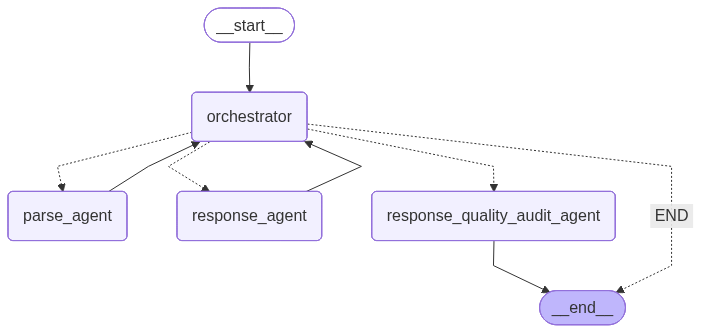

In [ ]:
# display the LangGraph workflow
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())


# **Test Cases**

## Test Case Execution Function

Runs the complete multi-agent graph on a single query, initializes the full shared state, executes the workflow, and returns a structured evaluation report containing confidence scores, tool accuracy metrics, reasoning coherence, HITL triggers, and total execution time.


In [ ]:
def test_case_execution(test_query, verbose=True):
    """Run the full graph on a single test query. Returns rich evaluation report."""

    initial_state = {
        # Core
        'user_query':                    test_query,
        'messages':                      [],
        # Parse
        'parsed_output':                 '',
        'refined_output':                '',
        'parse_route':                   '',
        'parse_confidence':              0.0,
        # Clarification
        'clarification_requested':       False,
        'clarification_query':           '',
        'user_clarification_response':   '',
        'clarification_resolved':        False,
        # RAG
        'case_chunks':                   '',
        'legal_chunks':                  '',
        'validation_status':             '',
        'retrieval_attempt':             0,
        'seen_legal_ids':                set(),
        'rag_chunks_confidence':         0.0,
        'tool_call_log':                 [],
        # Relevance & Groundedness
        'relevance_score':               None,
        'groundedness_score':            None,
        'relevance_groundedness_notes':  '',
        # Orchestration
        'next_agent':                    '',
        # Final
        'final_output':                  '',
        # Eval Metrics
        'correct_termination':           None,
        'tool_accuracy':                 None,
        'reasoning_coherence':           None,
        # HITL
        'hitl_1_triggered':              None,
        'hitl_2_triggered':              None,
        'hitl_reason':                   '',
        'hitl_stage':                    '',
        # Efficiency
        'run_start_time':                time.time(),
        'run_end_time':                  0.0,
        'total_latency_seconds':         0.0,
        'langsmith_run_id':              ''
    }

    result = app.invoke(initial_state)

    # Compute total latency (if not already set by hitl_node)
    if not result.get('total_latency_seconds'):
        result['total_latency_seconds'] = time.time() - initial_state['run_start_time']

    report = {
        'final_output':                  result.get('final_output'),
        # Confidence
        'parse_confidence':              result.get('parse_confidence'),
        'rag_chunks_confidence':         result.get('rag_chunks_confidence'),
        # Clarification
        'clarification_requested':       result.get('clarification_requested'),
        'clarification_resolved':        result.get('clarification_resolved'),
        'clarification_query':           result.get('clarification_query'),
        # Relevance & Groundedness
        'relevance_score':               result.get('relevance_score'),
        'groundedness_score':            result.get('groundedness_score'),
        'relevance_groundedness_notes':  result.get('relevance_groundedness_notes'),
        # Tool Accuracy
        'tool_call_log':                 result.get('tool_call_log'),
        'correct_termination':           result.get('correct_termination'),
        'tool_accuracy':                 result.get('tool_accuracy'),
        # Coherence
        'reasoning_coherence':           result.get('reasoning_coherence'),
        # HITL
        'hitl_1_triggered':              result.get('hitl_1_triggered'),
        'hitl_2_triggered':              result.get('hitl_2_triggered'),
        'hitl_stage':                    result.get('hitl_stage'),
        'hitl_reason':                   result.get('hitl_reason'),
        # Efficiency
        'total_execution_time':         result.get('total_latency_seconds')
    }

    if verbose:
        sep = '=' * 70
        mid = '─' * 70
        print(sep)
        print('FINAL OUTPUT')
        print(sep)
        print(result.get('final_output', ''))
        print()
        print(mid)
        print('EVALUATION REPORT')
        print(mid)
        print(f'  parse_confidence         : {report["parse_confidence"]}')
        print(f'  rag_chunks_confidence    : {report["rag_chunks_confidence"]}')
        print(f'  relevance_score          : {report["relevance_score"]}')
        print(f'  groundedness_score       : {report["groundedness_score"]}')
        print(f'  relevance and Groundedness notes : {report["relevance_groundedness_notes"]}')
        print(f'  tool_call_log            : {report["tool_call_log"]}')
        print(f'  correct_termination      : {report["correct_termination"]}')
        print(f'  tool_accuracy            : {report["tool_accuracy"]}')
        print(f'  reasoning_coherence      : {report["reasoning_coherence"]}')
        print(f'  clarification_requested  : {report["clarification_requested"]}')
        print(f'  clarification_resolved   : {report["clarification_resolved"]}')
        print(f'  hitl_1_triggered         : {report["hitl_1_triggered"]}')
        print(f'  hitl_2_triggered         : {report["hitl_2_triggered"]}')
        if report['hitl_stage']:
            print(f'  hitl_stage               : {report["hitl_stage"]}')
        if report['hitl_reason']:
            print(f'  hitl_reason              : {report["hitl_reason"]}')
        print(f'  total_execution_time    : {report["total_execution_time"]:.2f}s')
        print(mid)

    return report

## Test Case 1: Rent Increase Notice Requirement

**Query**: If my rent is being increased by more than 5%, is the landlord expected to provide the advance written notice based on how long I've lived in the apartment?

In [ ]:
test_case = "If my rent is being increased by more than 5%, is the landlord expected to provide the advance written notice based on how long I have lived in the apartment?"
result = test_case_execution(test_case)


────────────────────────────────────────────────────────────
CLARIFICATION REQUIRED
────────────────────────────────────────────────────────────
Question: Is your tenancy a fixed-term lease or a periodic tenancy?
────────────────────────────────────────────────────────────
Your answer: fixed-term
FINAL OUTPUT
If your rent is being increased by more than 5%, your landlord is required to provide advance written notice. The notice period depends on how long you have lived in the apartment:

- If you have been in occupancy for twenty-four months or more, or if your lease term was twenty-four months or longer, you are entitled to ninety-five days' notice.
- If you have resided in the unit for more than thirteen months but fewer than twenty-four months, you are entitled to sixty-five days' notice.
- For tenancies of thirteen months or less, the required notice is thirty-five days.

Failure to provide the appropriate notice may render the rent increase ineffective for the relevant period.

S

**Observation**

- The system correctly identified that statutory notice periods are predicated on tenancy specifics, and requested clarification from the user to obtain missing facts before generating a response.
- By resolving the ambiguity through user input, the agent achieved a perfect 5.0 groundedness score, successfully highlighting the three-tiered notice timeline and referencing a historical case.

## Test Case 2: Unauthorized Entry Dispute

**Query**: My landlord entered my apartment without giving prior notice while I was at work. There was no emergency, and I did not provide consent. Does this violate my right to privacy, and what remedies are available to me?

In [ ]:
test_case = "My landlord entered my apartment without giving prior notice while I was at work. There was no emergency, and I did not provide consent. Does this violate my right to privacy, and what remedies are available to me?"
result = test_case_execution(test_case)


────────────────────────────────────────────────────────────
CLARIFICATION REQUIRED
────────────────────────────────────────────────────────────
Question: Is your tenancy based on a written lease agreement or an oral agreement?
────────────────────────────────────────────────────────────
Your answer: written
FINAL OUTPUT
Your landlord's entry into your apartment without prior notice and without your consent, when there was no emergency, does indeed violate your right to privacy as a tenant. According to the policy content, a landlord must provide at least twenty-five hours' advance written notice before entering the unit, except in genuine emergencies. Since your situation does not qualify as an emergency, the landlord's actions are not permissible.

As for remedies available to you, you may consider the following options:

1. **Document the Incident**: Keep a record of the date and time of the unauthorized entry, as well as any communications with your landlord regarding this issue.


**Observation**

- The agent rightly paused to confirm the existence of a written lease, ensuring a more focused RAG search in subsequent steps.
- No supporting case is referenced because no relevant case from the archive applied to this scenario.

## Test Case 3: Out-of-Scope (Criminal) Query

**Query**: If someone steals my phone in a public place, what criminal charges apply and what punishment could they receive?

In [ ]:
test_case = "If someone steals my phone in a public place, what criminal charges apply and what punishment could they receive?"
result = test_case_execution(test_case)

FINAL OUTPUT
OUT_OF_SCOPE: This agent handles residential rental law queries only. Please ask an in-scope question.

──────────────────────────────────────────────────────────────────────
EVALUATION REPORT
──────────────────────────────────────────────────────────────────────
  parse_confidence         : 1.0
  rag_chunks_confidence    : 0.0
  relevance_score          : None
  groundedness_score       : None
  relevance and Groundedness notes : 
  tool_call_log            : []
  correct_termination      : None
  tool_accuracy            : None
  reasoning_coherence      : None
  clarification_requested  : YES
  clarification_resolved   : None
  hitl_1_triggered         : None
  hitl_2_triggered         : None
  total_execution_time    : 1.23s
──────────────────────────────────────────────────────────────────────


**Observation**

- The system correctly identifies the query as outside rental law and appropriately abstains from providing an answer, ensuring proper domain restriction.

## Test Case 4: Rent Regulation Status Clarification

**Query**: My landlord claims the apartment falls outside any rent regulation framework. What criteria determine whether a residential unit is subject to regulations?

In [ ]:
test_case = "My landlord claims the apartment falls outside any rent regulation framework. What criteria determine whether a residential unit is subject to regulations?"
result = test_case_execution(test_case)


────────────────────────────────────────────────────────────
CLARIFICATION REQUIRED
────────────────────────────────────────────────────────────
Question: Is there a written lease agreement for the apartment?
────────────────────────────────────────────────────────────
Your answer: yes
FINAL OUTPUT
The determination of whether a residential unit is subject to rent regulation frameworks depends on several criteria, including the building's age, size, and location, as well as the specific history of the individual tenancy. 

1. **Primary-Tier Rent Regulation**: This applies to residential buildings constructed before January 1, 1968, located in municipalities that have recognized a rental housing emergency. To qualify as a protected tenant under this regulation, the occupant must have maintained continuous residency in the apartment since before July 1, 1983.

2. **Secondary-Tier Rent Regulation**: This broader system generally applies to apartments in buildings constructed before Janua

**Observation**

- The agent correctly identified that establishing the existence of a formal lease was a necessary precursor, ensuring the subsequent steps were anchored in a documented tenancy.
- However, the cited case reference centers on the landlord's burden in luxury deregulation disputes and documentation compliance, which does not directly address the foundational criteria used to determine whether a unit is subject to regulation in the first instance.

## Test Case 5: Habitability Defense Contradiction

**Query**: I haven't paid rent for three months because my landlord hasn't fixed the elevator in my 10-story building. They just served me with court papers. Since this is a clear violation, can I sue the landlord for $25,000 in 'emotional distress' for the stress of climbing the stairs, and will the court automatically dismiss the eviction case because of this?

In [ ]:
test_case = "I haven't paid rent for three months because my landlord hasn't fixed the elevator in my 10-story building. They just served me with court papers. Since this is a clear violation, can I sue the landlord for $25,000 in 'emotional distress' for the stress of climbing the stairs, and will the court automatically dismiss the eviction case because of this?"
result = test_case_execution(test_case)


────────────────────────────────────────────────────────────
CLARIFICATION REQUIRED
────────────────────────────────────────────────────────────
Question: Did you formally request the elevator repairs from your landlord in writing?
────────────────────────────────────────────────────────────
Your answer: yes
FINAL OUTPUT
I couldn't find the relevant information to answer your query. Your query has been escalated to a Human Agent.

──────────────────────────────────────────────────────────────────────
EVALUATION REPORT
──────────────────────────────────────────────────────────────────────
  parse_confidence         : 0.85
  rag_chunks_confidence    : 0.85
  relevance_score          : 1.0
  groundedness_score       : 1.0
  relevance and Groundedness notes : The response does not address the user's query at all, as it simply states that the query has been escalated without providing any legal information. Additionally, the response is not grounded in the retrieved evidence, as it does no

**Observation**

- The agent exhausted the maximum retrieval attempts but failed to find evidence supporting the user's query regarding the validity of "*$25,000 in emotional distress*" or "*automatic dismissal*".
- Since the agent could not generate a grounded answer, it triggered HITL-2 due to a critical 1.0 groundedness score, rerouting the high-stakes query for human review.

# **Efficiency & Task Completion Dashboard**

This section fetches execution metrics from **LangSmith** for all runs in the current project. It computes and displays:

- **Task completion rate** - fraction of runs that produced a valid `final_output` (not escalated and not OUT_OF_SCOPE).
- **Average end-to-end latency** - mean seconds per run across the project.
- **Latency distribution** - min, max, median.
- **Token usage** - average prompt tokens and completion tokens per run.
- **Token cost** - average prompt cost and completion cost per run.
- **Tool invocation counts** - how many times each tool was called across all runs.
- **HITL escalation rate** - fraction of runs that triggered HITL-1 or HITL-2.

Metrics are aggregated across the **last N runs** in the LangSmith project (`LANGCHAIN_PROJECT` from the `config.json`).
- `MAX_RUNS` can be adjusted to control the window.

#### Fetch LangSmith Run Traces

This function fetches the most recent top-level runs (up to `max_runs`) from the specified LangSmith project and returns them as a list for aggregated evaluation and performance analysis.


In [ ]:
def fetch_langsmith_runs(max_runs: int = 5) -> list:
    """
    Fetch the most recent `max_runs` top-level runs from LangSmith
    for the current project (LANGCHAIN_PROJECT env var).
    Returns a list of run dicts with relevant fields.
    """
    client = Client()
    project_name = os.environ.get('LANGCHAIN_PROJECT', 'default')

    # print(f'Fetching up to {max_runs} runs from LangSmith project: "{project_name}"...')

    runs = list(client.list_runs(
        project_name=project_name,
        execution_order=1,          # top-level runs only
        limit=max_runs,
        error=None                  # include both successful and errored runs
    ))

    # print(f'Fetched {len(runs)} runs.')
    return runs

#### Parse Individual Run Metadata

This function parses LangSmith run objects to extract structured metadata, including latency, token usage, cost breakdown, tool calls, final output classification, and task completion status—and returns a list of standardized records for aggregated performance analysis.


In [ ]:
def parse_run_metadata(runs: list) -> list:
    """
    Extract relevant fields from each LangSmith run object.
    Returns a list of dicts - one per run.
    """
    records = []
    for run in runs:
        # ── Latency ───────────────────────────────────────────────
        latency_s = None
        if run.start_time and run.end_time:
            delta     = run.end_time - run.start_time
            latency_s = delta.total_seconds() if hasattr(delta, 'total_seconds') else float(delta)

        # ── Token Usage ──────────────────────────────────────────
        token_usage = run.total_tokens or 0
        prompt_tok  = (run.prompt_tokens     or 0)
        compl_tok   = (run.completion_tokens or 0)

        # ── Outputs ──────────────────────────────────────────────
        outputs         = run.outputs or {}
        raw_final_out   = outputs.get('final_output', '') or ''

        if isinstance(raw_final_out, list):
            final_out = " ".join([str(m) for m in raw_final_out])
        else:
            final_out = str(raw_final_out)

        # ── Task Completion Classification ────────────────────────
        is_out_of_scope = 'OUT_OF_SCOPE' in final_out
        is_hitl_escaped = 'Human Agent' in final_out
        is_no_info      = 'information is insufficient' in final_out
        task_completed  = (
            not is_out_of_scope
            and not is_hitl_escaped
            and not is_no_info
            and len(final_out.strip()) > 50
            and run.error is None
        )

        # ── Cost Extraction from LangSmith ─────────────────────────
        total_cost = float(run.total_cost) if getattr(run, "total_cost", None) else 0.0
        prompt_cost = float(run.prompt_cost) if getattr(run, "prompt_cost", None) else 0.0
        completion_cost = float(run.completion_cost) if getattr(run, "completion_cost", None) else 0.0

        # ── Tool Call Log from Outputs ────────────────────────────
        tool_log = outputs.get('tool_call_log', []) or []

        records.append({
            'run_id':         str(run.id),
            'run_name':       run.name,
            'status':         run.status,
            'error':          run.error,
            'latency_s':      latency_s,
            'total_tokens':   token_usage,
            'prompt_tokens':  prompt_tok,
            'compl_tokens':   compl_tok,
            'total_cost_usd': total_cost,
            'prompt_cost_usd': prompt_cost,
            'completion_cost_usd': completion_cost,
            'task_completed': task_completed,
            'is_out_of_scope': is_out_of_scope,
            'is_hitl_escaped': is_hitl_escaped,
            'tool_log':        tool_log,
            'final_output_len': len(final_out)
        })

    return records

#### Aggregated Metrics Computation

This function computes aggregated performance metrics from parsed LangSmith run records, including task completion and escalation rates, latency statistics, average token usage, tool invocation counts, and cost analysis, returning a consolidated summary for system-level evaluation.


In [ ]:
def compute_aggregate_metrics(records: list) -> Dict[str, Any]:
    """
    Compute aggregated efficiency and task completion metrics
    from the list of parsed run records.
    """
    import statistics

    if not records:
        print('No run records to aggregate.')
        return {}

    total_runs = len(records)

    # ── Task Completion Rate ──────────────────────────────────────
    completed       = [r for r in records if r['task_completed']]
    out_of_scope    = [r for r in records if r['is_out_of_scope']]
    hitl_escalated  = [r for r in records if r['is_hitl_escaped']]
    errored         = [r for r in records if r['error']]

    completion_rate = len(completed) / total_runs
    oos_rate        = len(out_of_scope) / total_runs
    hitl_rate       = len(hitl_escalated) / total_runs
    error_rate      = len(errored) / total_runs

    # ── Latency ──────────────────────────────────────────────────
    latencies = [r['latency_s'] for r in records if r['latency_s'] is not None]
    if latencies:
        latencies_sorted = sorted(latencies)
        n = len(latencies_sorted)
        lat_mean = statistics.mean(latencies_sorted)
        lat_min  = latencies_sorted[0]
        lat_max  = latencies_sorted[-1]
        lat_median  = latencies_sorted[int(n * 0.50)]
    else:
        lat_mean = lat_min = lat_max = lat_median = 0

    # ── Token Usage ──────────────────────────────────────────────
    prompt_tokens = [r['prompt_tokens'] for r in records if r['prompt_tokens']]
    compl_tokens  = [r['compl_tokens']  for r in records if r['compl_tokens']]
    avg_prompt    = statistics.mean(prompt_tokens) if prompt_tokens else 0
    avg_compl     = statistics.mean(compl_tokens)  if compl_tokens  else 0

    # ── Tool Invocation Counts ────────────────────────────────────
    tool_counts: Dict[str, int] = {}
    for r in records:
        for tool in r.get('tool_log', []):
            tool_counts[tool] = tool_counts.get(tool, 0) + 1

    # ── Cost Metrics ──────────────────────────────────────────────
    costs = [r['total_cost_usd'] for r in records]
    prompt_costs = [r['prompt_cost_usd'] for r in records]
    completion_costs = [r['completion_cost_usd'] for r in records]

    total_cost = sum(costs)
    avg_cost = total_cost / total_runs if total_runs else 0

    total_prompt_cost = sum(prompt_costs)
    total_completion_cost = sum(completion_costs)

    metrics = {
        'total_runs':               total_runs,
        'task_completion_rate':     completion_rate,
        'out_of_scope_rate':        oos_rate,
        'hitl_escalation_rate':     hitl_rate,
        'error_rate':               error_rate,
        'latency_mean_s':           lat_mean,
        'latency_min_s':            lat_min,
        'latency_max_s':            lat_max,
        'latency_median':            lat_median,
        'avg_prompt_tokens':        avg_prompt,
        'avg_output_tokens':    avg_compl,
        'tool_invocation_counts':   tool_counts,
        'avg_cost_per_run_usd': avg_cost,
        'total_cost_usd': total_cost,
        'total_prompt_cost_usd': total_prompt_cost,
        'total_completion_cost_usd': total_completion_cost,
    }

    return metrics

#### Dashboard Generation

This function generates a formatted efficiency dashboard summarizing aggregated metrics—including task completion rates, escalation rates, latency statistics, token usage, cost breakdown, and tool invocation counts—providing a consolidated performance overview.


In [ ]:
def print_efficiency_dashboard(metrics: Dict[str, Any]) -> None:
    """
    Print a formatted efficiency and task completion dashboard.
    """
    if not metrics:
        print('No metrics to display.')
        return

    sep = '=' * 65
    mid = '─' * 65
    print()
    print(sep)
    print('RENTAL LAW AGENT - EFFICIENCY & TASK COMPLETION DASHBOARD')
    print(sep)

    print(f"\n  TASK COMPLETION  (N={metrics['total_runs']} runs)")
    print(mid)
    print(f"  Task Completion Rate    : {metrics['task_completion_rate']:.1%}")
    print(f"  Out-of-Scope Rate       : {metrics['out_of_scope_rate']:.1%}")
    print(f"  HITL Escalation Rate    : {metrics['hitl_escalation_rate']:.1%}")
    print(f"  Error Rate              : {metrics['error_rate']:.1%}")

    print(f"\n  LATENCY (seconds)")
    print(mid)
    print(f"  Mean                    : {metrics['latency_mean_s']:.2f}s")
    print(f"  Min                     : {metrics['latency_min_s']:.2f}s")
    print(f"  Max                     : {metrics['latency_max_s']:.2f}s")
    print(f"  Median                  : {metrics['latency_median']:.2f}s")

    print(f"\n  TOKEN USAGE (averages per run)")
    print(mid)
    print(f"  Avg Prompt Tokens       : {metrics['avg_prompt_tokens']:.0f}")
    print(f"  Avg Output Tokens       : {metrics['avg_output_tokens']:.0f}")
    print(f"  Avg Total Tokens        : {metrics['avg_prompt_tokens'] + metrics['avg_output_tokens']:.0f}")

    print(f"\n  COST METRICS (USD)")
    print(mid)
    print(f"  Total Cost              : ${metrics['total_cost_usd']:.6f}")
    print(f"  Total Prompt Cost       : ${metrics['total_prompt_cost_usd']:.6f}")
    print(f"  Total Output Cost       : ${metrics['total_completion_cost_usd']:.6f}")
    print(f"  Avg Cost per Run        : ${metrics['avg_cost_per_run_usd']:.6f}")

#### Rendering the Dashboard

We now fetch LangSmith traces and render the dashboard.
- We can set `MAX_RUNS` to control how many recent runs are included in the aggregation.

In [ ]:
# ─── Configuration ───────────────────────────────────────────────────────
MAX_RUNS = 5

# ─── Fetch + Parse ───────────────────────────────────────────────────────
raw_runs   = fetch_langsmith_runs(max_runs=MAX_RUNS)
run_records = parse_run_metadata(raw_runs)

# ─── Aggregate ───────────────────────────────────────────────────────────
agg_metrics = compute_aggregate_metrics(run_records)

# ─── Display ─────────────────────────────────────────────────────────────
print_efficiency_dashboard(agg_metrics)


RENTAL LAW AGENT - EFFICIENCY & TASK COMPLETION DASHBOARD

  TASK COMPLETION  (N=5 runs)
─────────────────────────────────────────────────────────────────
  Task Completion Rate    : 60.0%
  Out-of-Scope Rate       : 20.0%
  HITL Escalation Rate    : 20.0%
  Error Rate              : 0.0%

  LATENCY (seconds)
─────────────────────────────────────────────────────────────────
  Mean                    : 72.20s
  Min                     : 1.23s
  Max                     : 205.51s
  Median                  : 41.45s

  TOKEN USAGE (averages per run)
─────────────────────────────────────────────────────────────────
  Avg Prompt Tokens       : 40588
  Avg Output Tokens       : 3526
  Avg Total Tokens        : 44114

  COST METRICS (USD)
─────────────────────────────────────────────────────────────────
  Total Cost              : $0.104213
  Total Prompt Cost       : $0.085053
  Total Output Cost       : $0.019160
  Avg Cost per Run        : $0.020843


# **Limitations and Remedies**

## Limitations

* The current implementation blindly incorporates retrieved document chunks and user clarification responses into the combined_query. This leaves the system vulnerable to indirect prompt injection.

* The centralized **`UnifiedState`** architecture increases coordination efficiency but introduces potential risks related to state integrity, isolation, and unintended data propagation in multi-user or production environments.

## Remedies

* Implement a dedicated "Guardrail Node" to safeguard the user inputs and retrieved content for prompt injection.

* Enforce strict `UnifiedState` schema validation, session isolation, and access control mechanisms (e.g., RBAC, authentication, encryption) to ensure secure and compliant multi-agent execution.